In [18]:
print("Using GINI ---")

Using GINI ---


In [19]:
import numpy as np
import pandas as pd 

In [20]:
df = pd.read_csv("D:\Practice_SMJ\Social_Network_Ads.csv")

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\bda\AppData\Local\Temp\ipykernel_10232\1503186162.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df = pd.read_csv("D:\Practice_SMJ\Social_Network_Ads.csv")


In [21]:
display(df)

,User ID,Gender,Age,Estimated_Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [22]:
# x = age 
# y = estimated salary 
# we will predict purchaed or not 
df.isnull().sum() 

User ID             0
Gender              0
Age                 0
Estimated_Salary    0
Purchased           0
dtype: int64

In [23]:
X = df[["Age", "Estimated_Salary"]]  # input / feature
y = df["Purchased"]   # target / output

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)



In [26]:
sc = StandardScaler()
X_train= sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test

array([[ 0.82778356, -1.43382709],
       [ 2.10507569,  0.51377487],
       [-0.94077478, -0.78462644],
       [ 1.02429004,  0.74984783],
       [-0.84252154, -1.25677236],
       [-0.7442683 , -0.25346227],
       [ 0.9260368 ,  1.07444816],
       [-0.84252154,  0.36622926],
       [ 0.23826411,  0.1301563 ],
       [ 0.43477059, -0.16493491],
       [-0.2530021 , -0.16493491],
       [ 1.51555624, -1.07971764],
       [-1.43204099, -0.66658995],
       [-1.72680071, -1.40431797],
       [-0.7442683 ,  0.48426575],
       [-0.2530021 ,  1.10395728],
       [ 1.417303  , -0.96168116],
       [ 0.82778356,  0.10064718],
       [ 0.14001087, -0.84364468],
       [ 1.81031597, -0.31248051],
       [-1.53029423, -1.28628149],
       [-0.84252154,  0.2777019 ],
       [ 0.9260368 , -1.40431797],
       [ 2.10507569,  0.15966542],
       [-1.82505395, -1.52235445],
       [ 1.31904976, -1.40431797],
       [ 0.43477059,  0.2777019 ],
       [-0.05649561, -0.51904435],
       [ 1.71206273,

In [27]:
# fitting Gini to traning set
classifier = DecisionTreeClassifier(criterion="gini", random_state=0)
classifier.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [28]:
#predicting test set results
y_pred = classifier.predict(X_test)

print("Predicted values:-")
print(y_pred)

print("Actual values:-")
print(y_test.values)

Predicted values:-
[1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0
 1 0 1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 0 0
 1 1 1 1 0 0 1 0 0]
Actual values:-
[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0
 0 1 1 1 0 0 1 0 0]


In [29]:
from sklearn.metrics import confusion_matrix
# maring confusion Matrix to compare
cm = confusion_matrix(y_test , y_pred)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")
print("Error:", (1 - accuracy) * 100, "%")


Accuracy: 84.16666666666667 %
Error: 15.833333333333332 %


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        73
           1       0.80      0.79      0.80        47

    accuracy                           0.84       120
   macro avg       0.83      0.83      0.83       120
weighted avg       0.84      0.84      0.84       120



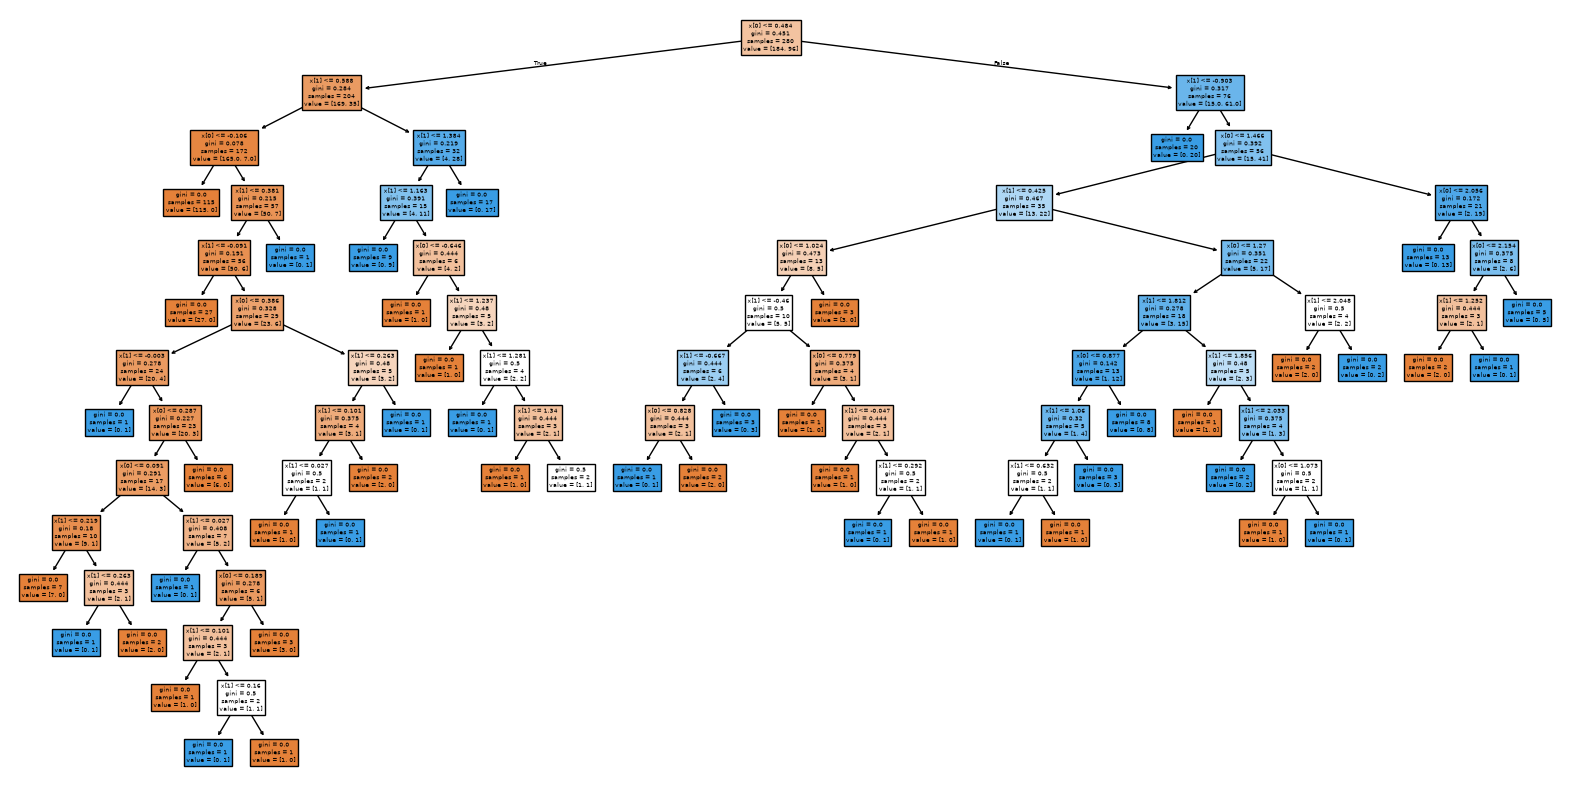

In [32]:
#from sklearn import tree 

#tree.plot_tree(classifier)
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

tree.plot_tree(
    classifier,
    filled=True
)

plt.show()
